##### Import statements:

In [130]:
import os
import pathlib
import inspect
import functools
import pickle
import numpy as np
import pandas as pd
import json
import socket
import multiprocessing as mp
import functools
import itertools
import torch
import matplotlib.pyplot as plt

hostname = socket.gethostname()

if 'rc.zi.columbia.edu' in hostname:
    from ws.general import find_df_constants, matches_template, class_def2str
    from ws.simulate_task import load_sim_params, load_task_def, simulate_session
    from ws.miscellaneous_sparseauto import mdl_geometry_pipeline, fmt_ae_metadata, generate_hparams_df, causal_mask
    from ws.plot import plot_iterate_autoencoder_results, plot_ccgps_by_layer, plot_pars_by_layer
    base = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws') 
else:
    from simulation_whiskers.general import find_df_constants, matches_template, class_def2str
    from simulation_whiskers.simulate_task import load_sim_params, load_task_def, simulate_session, causal_mask
    from simulation_whiskers.miscellaneous_sparseauto import mdl_geometry_pipeline, fmt_ae_metadata, generate_hparams_df, causal_mask
    #from simulation_whiskers.plot import plot_iterate_autoencoder_results, plot_autoencoder_geometry
    from simulation_whiskers.plot import plot_iterate_autoencoder_results, plot_ccgps_by_layer, plot_pars_by_layer
    base = os.path.join('C:\\', 'Users', 'danie' 'Documents', 'code_libraries', 'simulation_whiskers')

from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata
import time

##### Define parameters:

In [147]:
# Define task definitions:
task_defs = [
    
    # Task 0:
    [
     functools.partial(matches_template, template={'freq_sh' : 2}), 
     functools.partial(matches_template, template={'freq_sh' : 15})
     ],
    
    # Task 1:
    [
     functools.partial(matches_template, template={'time_mov' : 10}),
     functools.partial(matches_template, template={'time_mov' : 17})
     ]
    ]

# Define general variables:
n_files = 10
n_geo_subsamples = 1
sum_inpt=False
xor=True
zscore_data = False
sig_init = 1.0
save_learning = False
chunked_reconstruction_loss = False

# Define simulation parameters:
concavity = [0]
n_whisk = 2
prob_poiss = 1.01
noise_w = 0.3
spread = 'auto'
speed = 2.0
ini_phase_m = 0
ini_phase_spr = 100
delay_time = 0
freq_m = 3.0
freq_std = 0.1
std_reset = 0
t_total = 2
dt = 0.1
dx = 0.01
n_trials_pre = 50
amp = 2
freq_sh = [2, 15]
z1 = [4]
max_rad = 50
n_rad = 4
disp = 4.5
theta = [0]
steps_mov = [10, 17]
rad_vec = [6]
init_position = 0

# Entangler model parameters:
tngl_n_hidden = 80
tngl_beta_rec = 1.0
tngl_beta_pr = 1.0
tngl_beta_sp = 0
tngl_p_norm = 1
tngl_n_epochs = 50
tngl_batch_size = 64
tngl_lr = 0.001
tngl_sig_init = 1 
tngl_sig_neu = 0.1 

# Autoencoder parameters:
mdl_type = "autoencoder"
n_hidden = 20
sig_init = 1 
sig_neu = 0.1 
lr = 0.001
beta0 = 0
beta1 = 0
beta_rec = 0
beta_xor = 0
n_epochs = 50
batch_size = 10
beta_sp = 0
beta_pr = 0
p_norm = 2
n_splits = 5
n_predictor_bins = 10
n_predicted_bins = 4
n_offsets = 1

# Compute parameters:
gpu = False
n_cores = 1

# Do some custom, ad-hoc hyperparameter selection:
#beta_lins=10**np.arange(0, 5, 1)
beta_lins= [10**2.5]
#beta_lins = np.array([0] + list(beta_lins))
#beta_lins = [0, 10**2.5, 10**5]
#n_hiddens = [40, 240]
n_hiddens = [40]
hparams = [{'beta_rec':x[0], 'n_hidden':x[1]} for x in list(itertools.product(beta_lins, n_hiddens))]
#hparams = None

# Output directory:
if 'rc.zi.columbia' in hostname:
    base_output_directory = os.path.join(base, 'results')
else:
    base_output_directory='E:\\simulation_whiskers\\results\\'
run_base_name='run'
sv=False

##### Deal with some preliminaries:

In [148]:
simulation_cols = ['concavity', 'n_whisk', 'prob_poiss', 'noise_w', 'spread',
     'speed', 'ini_phase_m', 'ini_phase_spr', 'delay_time', 'freq_m', 'freq_std',
     'std_reset', 't_total', 'dt', 'dx', 'n_trials_pre', 'n_files', 'amp', 'freq_sh',
     'z1', 'max_rad', 'n_rad', 'disp', 'theta', 'steps_mov', 'rad_vec', 'init_position']

autoencoder_cols = ['mdl_type', 'n_hidden', 'sig_init', 'sig_neu', 'lr', 'beta0',
    'beta1', 'beta_rec', 'beta_xor', 'n_epochs', 'batch_size', 'beta_sp', 'p_norm',
    'beta_pr', 'n_splits', 'n_predictor_bins', 'n_predicted_bins', 'n_offsets']

# TODO: A lot of this seems really inefficient; streamline this somehow?

# Put simulation params into dict:
sim_params = {
    'n_whisk' : n_whisk,
    'prob_poiss' : prob_poiss,
    'noise_w' : noise_w,
    'spread' : spread,
    'speed' : speed,
    'ini_phase_m' : ini_phase_m,
    'ini_phase_spr' : ini_phase_spr, 
    'delay_time' : delay_time, 
    'freq_m' : freq_m, 
    'freq_std' : freq_std,
    'std_reset' : std_reset,
    't_total' : t_total,
    'dt' : dt,
    'dx' : dx,
    'n_trials_pre' : n_trials_pre, 
    'amp' : amp,
    'freq_sh' : freq_sh,
    'z1' : z1,
    'max_rad' : max_rad,
    'n_rad' : n_rad,
    'disp' : disp,
    'theta' : theta,
    'steps_mov' : steps_mov,
    'rad_vec' : rad_vec,
    'init_position' : init_position,
}

n_feat = n_whisk*2

##### Simulate initial whisker data used to fit entangler model:

In [149]:
# Simulate train and test sessions: 
tngl_train_session=simulate_session(sim_params, sum_bins=False)
tngl_train_session['split'] = 'train'
tngl_train_session['trial_num'] = np.arange(tngl_train_session.shape[0])

tngl_test_session=simulate_session(sim_params, sum_bins=False)
tngl_test_session['split'] = 'test'
tngl_test_session['trial_num'] = np.arange(tngl_test_session.shape[0])

# Merge train and test:
tngl_sim_df = pd.concat([tngl_train_session, tngl_test_session], axis=0)

# Unrwap features:
tngl_sim_df['features'] = tngl_sim_df.apply(lambda x : np.reshape(x.features,-1), axis=1)

# Split into predicted and predictor features:
tngl_sim_df = causal_mask(tngl_sim_df, n_feat, n_predictor_bins, n_predicted_bins, n_offsets)
tngl_sim_df['predicted_features'] = tngl_sim_df['predictor_features'] # Predicted and predictor features will be same for entangling autoencoder

##### Fit entangler model:

In [150]:
tngl_mdl_params = {
    'mdl_type' : "autoencoder",
    'n_hidden' : tngl_n_hidden,
    'beta_rec' : tngl_beta_rec,
    'beta_pr' : tngl_beta_pr,    
    'beta_sp' : tngl_beta_sp,    
    'n_epochs' : tngl_n_epochs, 
    'batch_size' : tngl_batch_size,
    'lr' : tngl_lr, 
    'p_norm' : tngl_p_norm, 
    'sig_init' : tngl_sig_init,
    'sig_neu' :  tngl_sig_neu,
    'beta0' : 0,
    'beta1' : 0,
    'beta_xor' : 0,
}

tngl_results = mdl_geometry_pipeline(sim_params, task_defs, tngl_mdl_params, sessions_in=tngl_sim_df, save_learning=False, sum_inpt=False)

Fitting autoencoder...
0 rec  0.17679482698440552 ce  0.0 sp  0.14389657974243164 total  -21.154524981975555
49 rec  0.08085325360298157 ce  0.0 sp  0.08309124410152435 total  -66.11876222491264
fit_autoencoder duration=1.7280194759368896


##### Generate dataframe of hyperparameters for main model:

In [154]:
hparams_df = generate_hparams_df(hparams=hparams, task_defs=task_defs, n_files=n_files, 
     xor=xor, n_geo_subsamples=n_geo_subsamples, zscore_data=zscore_data, 
     save_perf=False, sum_inpt=sum_inpt, chunked_reconstruction_loss=False, 
     save_learning=save_learning, gpu=gpu, save_sessions=False, verbose=False, 
     concavity=concavity, n_whisk=n_whisk, prob_poiss=prob_poiss, noise_w=noise_w, 
     spread=spread, speed=speed, ini_phase_m=ini_phase_m, ini_phase_spr=ini_phase_spr, 
     delay_time=delay_time, freq_m=freq_m, freq_std=freq_std, std_reset=std_reset, 
     t_total=t_total, dt=dt, dx=dx, n_trials_pre=n_trials_pre, n_repeats=n_files, 
     amp=amp, freq_sh=freq_sh, z1=z1, max_rad=max_rad, n_rad=n_rad, disp=disp, 
     theta=theta, steps_mov=steps_mov, rad_vec=rad_vec, init_position=init_position, 
     mdl_type=mdl_type, n_hidden=n_hidden, sig_init=sig_init, sig_neu=sig_neu, 
     lr=lr, beta0=beta0, beta1=beta1, beta_rec=beta_rec, beta_xor=beta_xor, 
     beta_sp=beta_sp, beta_pr=beta_pr, n_epochs=n_epochs, batch_size=batch_size, 
     p_norm=p_norm, n_splits=n_splits, n_predictor_bins=n_predictor_bins, 
     n_predicted_bins=n_predicted_bins, n_offsets=n_offsets)

# Verify parameters before executing:
hparam_strs = list(hparams_df.apply(lambda x : 'model={}, n_hidden={}, beta_rec={}, beta_sp={}, beta_pr={}, n_epochs={}'.format(x.mdl_type,x.n_hidden, x.beta_rec, x.beta_sp, x.beta_pr, x.n_epochs), axis=1))
print('Running following hyperparameters:\n')
print('\n'.join(hparam_strs))
yn = input('\nProceed? (y/n)')
if '__file__' not in dir():
    if yn == 'y':
        pass
    else: 
        raise AssertionError('User aborted execution.')

Running following hyperparameters:

model=autoencoder, n_hidden=40, beta_rec=316.22776601683796, beta_sp=0, beta_pr=0, n_epochs=50
model=autoencoder, n_hidden=40, beta_rec=316.22776601683796, beta_sp=0, beta_pr=0, n_epochs=50
model=autoencoder, n_hidden=40, beta_rec=316.22776601683796, beta_sp=0, beta_pr=0, n_epochs=50
model=autoencoder, n_hidden=40, beta_rec=316.22776601683796, beta_sp=0, beta_pr=0, n_epochs=50
model=autoencoder, n_hidden=40, beta_rec=316.22776601683796, beta_sp=0, beta_pr=0, n_epochs=50
model=autoencoder, n_hidden=40, beta_rec=316.22776601683796, beta_sp=0, beta_pr=0, n_epochs=50
model=autoencoder, n_hidden=40, beta_rec=316.22776601683796, beta_sp=0, beta_pr=0, n_epochs=50
model=autoencoder, n_hidden=40, beta_rec=316.22776601683796, beta_sp=0, beta_pr=0, n_epochs=50
model=autoencoder, n_hidden=40, beta_rec=316.22776601683796, beta_sp=0, beta_pr=0, n_epochs=50
model=autoencoder, n_hidden=40, beta_rec=316.22776601683796, beta_sp=0, beta_pr=0, n_epochs=50



Proceed? (y/n) y


##### Generate simulated trials for each set of hyperparameters:

In [155]:
# Generate simulated contacts:
sim_df = pd.DataFrame()
for hidx, hparams in hparams_df.iterrows():

    # Test:
    curr_train_sim = simulate_session(sim_params, sum_bins=False)
    curr_train_sim['split'] = 'train'
    curr_train_sim['trial_num'] = np.arange(curr_train_sim.shape[0])

    # Train:
    curr_test_sim = simulate_session(sim_params, sum_bins=False)
    curr_test_sim['split'] = 'test'
    curr_test_sim['trial_num'] = np.arange(curr_train_sim.shape[0])

    # Merge:
    curr_sim = pd.concat([curr_train_sim, curr_test_sim], axis=0)
    curr_sim['sim_idx'] = hidx
    sim_df = pd.concat([sim_df, curr_sim], axis=0)

# Unrwap features:
sim_df['features'] = sim_df.apply(lambda x : np.reshape(x.features,-1), axis=1)

# Split simulated whisker data into predicted and predictor features:
sim_df = causal_mask(sim_df, n_feat, n_predictor_bins, n_predicted_bins, n_offsets)

# Pass predictor features through entangler model:
sim_df['predictor_features'] = sim_df.apply(lambda x : entangler.enc(torch.Tensor(x.predictor_features.astype(np.float32))).detach().numpy(), axis=1)

##### Iterate over hyperparameters, fit models, analyze geometry on each:

In [156]:
# Iterate over dicts of hyperparamter combos:
pred_geo_results = pd.DataFrame()
pred_perf_results = pd.DataFrame()
pred_ae_results = pd.DataFrame()
start = time.time()
start = time.time()
for hidx, curr_hparams in hparams_df.iterrows():

    # Get current model hypermarameter set:
    curr_autoencoder_params = dict(curr_hparams[autoencoder_cols])

    # Fit model, test geometry:
    curr_results=mdl_geometry_pipeline(sim_params,  
        tasks=curr_hparams.task_defs, autoencoder_params=curr_autoencoder_params, xor=curr_hparams.xor, 
        n_geo_subsamples=curr_hparams.n_geo_subsamples, zscore_data=curr_hparams.zscore_data, 
        save_perf=False, sum_inpt=curr_hparams.sum_inpt, chunked_reconstruction_loss=curr_hparams.chunked_reconstruction_loss, 
        save_learning=curr_hparams.save_learning, gpu=curr_hparams.gpu, save_sessions=False, 
        verbose=True)

    curr_hparams_df = pd.DataFrame(hparams_df.iloc[0]).T

    # Extract geometry results, add metadata:
    curr_geo_results = curr_results['geo_df']
    geo_meta_cols = list(set(curr_hparams_df) - set(curr_geo_results.columns))
    geo_meta = pd.concat([curr_hparams_df[geo_meta_cols]]*curr_geo_results.shape[0],axis=0)
    geo_meta.index = np.arange(geo_meta.shape[0])
    curr_geo_results = pd.concat([curr_geo_results, geo_meta], axis=1)
    pred_geo_results = pd.concat([pred_geo_results, curr_geo_results], axis=0)
    
    # Extract classifier performance results, add metadata:
    curr_perf_results = curr_results['perf_df']
    perf_meta_cols = list(set(curr_hparams_df) - set(curr_perf_results.columns))
    perf_meta = pd.concat([curr_hparams_df[perf_meta_cols]]*curr_perf_results.shape[0],axis=0)
    perf_meta.index = np.arange(perf_meta.shape[0])
    curr_perf_results = pd.concat([curr_perf_results, perf_meta], axis=1)
    pred_perf_results = pd.concat([pred_perf_results, curr_perf_results], axis=0)

    # Extract autoencoder representations, add metadata:
    if curr_results['ae_df'] is not None:            
        curr_ae_results = curr_results['ae_df']
        ae_meta_cols = list(set(curr_hparams_df) - set(curr_ae_results.columns))
        ae_meta = pd.concat([curr_hparams_df[ae_meta_cols]]*curr_ae_results.shape[0],axis=0)
        curr_ae_results = pd.concat([curr_ae_results, perf_meta], axis=1)
        pred_ae_results = pd.concat([pred_ae_results, curr_ae_results])

pred_geo_results['train_partition'] = pred_geo_results.apply(lambda x :str(x.train_partition), axis=1)

pred_results = dict()
pred_results['geo_df'] = pred_geo_results
pred_results['perf_df'] = pred_perf_results
pred_results['ae_df'] = pred_ae_results

geo_df = pd.concat([]

all_results = dict()

Simulating whisker contact data...
simulate_session duration=1.2113111019134521
Fitting autoencoder...
0 rec  0.19232450425624847 ce  0.0 sp  0.04050540179014206 total  61.5128153989678
49 rec  0.006569874472916126 ce  0.0 sp  1.0762012004852295 total  2.733013004970844
fit_autoencoder duration=3.5181028842926025
Simulating whisker contact data...
simulate_session duration=1.2252886295318604
Fitting autoencoder...
0 rec  0.19707146286964417 ce  0.0 sp  0.031538888812065125 total  63.02827281791058
49 rec  0.00660742400214076 ce  0.0 sp  1.1664233207702637 total  2.746540641558603
fit_autoencoder duration=3.530829429626465
Simulating whisker contact data...
simulate_session duration=1.226278305053711
Fitting autoencoder...
0 rec  0.2095024734735489 ce  0.0 sp  0.03599155321717262 total  66.94184729701357
49 rec  0.0062798187136650085 ce  0.0 sp  1.0476783514022827 total  2.641261127205566
fit_autoencoder duration=3.505751132965088
Simulating whisker contact data...
simulate_session dura

In [191]:
tngl_geo = tngl_results['geo_df']
pred_geo = pred_results['geo_df']
tngl_geo.shape

(16, 11)

In [194]:
pred_geo.model_type

0     autoencoder
1     autoencoder
2     autoencoder
3     autoencoder
4     autoencoder
         ...     
11    autoencoder
12    autoencoder
13    autoencoder
14    autoencoder
15    autoencoder
Name: model_type, Length: 160, dtype: object

In [188]:
pd.concat([pred_geo_results,tngl_geo], axis=0).shape

(176, 69)

In [174]:
type(pred_geo.iloc[0].parallelism)

numpy.float64

In [185]:
pred_ps = pred_geo[['repeat_idx', 'dichotomy', 'train_partition','parallelism']]\
    .groupby(['repeat_idx', 'dichotomy', 'train_partition']).mean()\
    .groupby(['repeat_idx', 'dichotomy']).mean()\
    .groupby(['repeat_idx']).mean().reset_index()
pred_ps

,repeat_idx,parallelism
0,0,0.30669


Text(0, 0.5, 'Entangler model participation ratio loss')

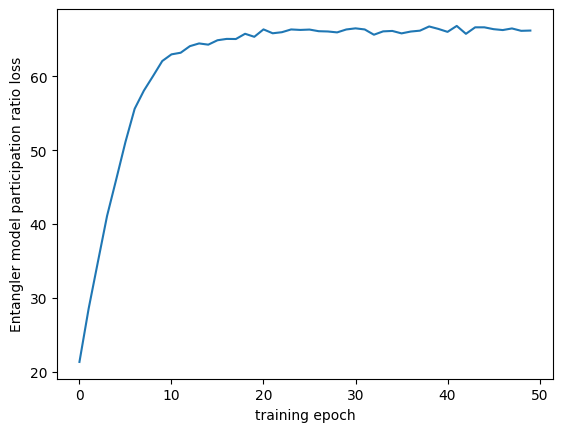

In [181]:
tngl_ae = tngl_results['ae_df']
plt.plot(tngl_ae.loss_pr)
plt.xlabel('training epoch')
plt.ylabel('Entangler model participation ratio loss')

Text(0, 0.5, 'Parallelism score (PS)')

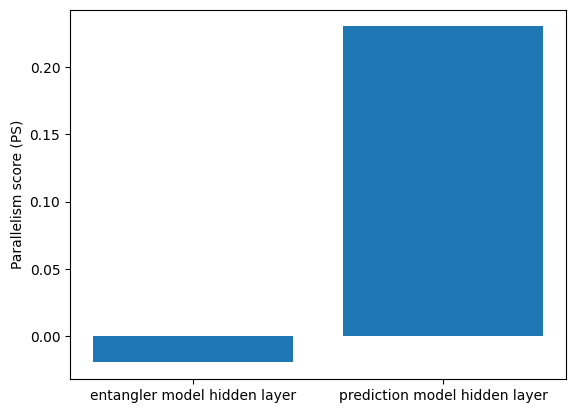

In [136]:
T = np.mean(np.mean(tngl_geo[tngl_geo.layer=='hidden']['parallelism']))
P = np.mean(np.mean(pred_geo[pred_geo.layer=='hidden']['parallelism']))

plt.bar([0,1], [T,P])
plt.xticks([0,1], labels=['entangler model hidden layer', 'prediction model hidden layer'])
plt.ylabel('Parallelism score (PS)')